In [3]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import ListedColormap
from matplotlib.cm import get_cmap
import pandas as pd

# Define a function to extract data from the eigenvalue files
def parse_eigenvalue_file(filename):
    """
    Parse eigenvalue files from MLegS output.
    
    Parameters:
    -----------
    filename : str
        Path to the eigenvalue file
        
    Returns:
    --------
    dict
        Dictionary containing the parsed data
    """
    # Extract parameters from filename
    pattern = r"bsnsq_eig_MK_\s*([0-9.-]+)_([0-9]+)_\s*([0-9.-]+)_NRCHOP_(\d+)"
    match = re.search(pattern, filename)
    
    if not match:
        print(f"Couldn't parse parameters from {filename}")
        return None
    
    bv_freq = float(match.group(1))
    m = int(match.group(2))
    k = float(match.group(3))
    nrchop = int(match.group(4))
    
    # Parse file content
    eigenvalues = []
    is_resolved = []
    indices = []
    
    with open(filename, 'r') as file:
        for line in file:
            # Match the eigenvalue format
            match = re.search(r'II\s*=\s*(\d+)\s*:\s*\(([^,]+),([^)]+)\)\s*-\s*([TF])', line)
            if match:
                index = int(match.group(1))
                real_part = float(match.group(2))
                imag_part = float(match.group(3))
                resolved = match.group(4) == 'T'
                
                indices.append(index)
                eigenvalues.append(complex(real_part, imag_part))
                is_resolved.append(resolved)
    
    return {
        'bv_freq': bv_freq,
        'm': m,
        'k': k,
        'nrchop': nrchop,
        'indices': np.array(indices),
        'eigenvalues': np.array(eigenvalues),
        'is_resolved': np.array(is_resolved)
    }


Processed 15 files.


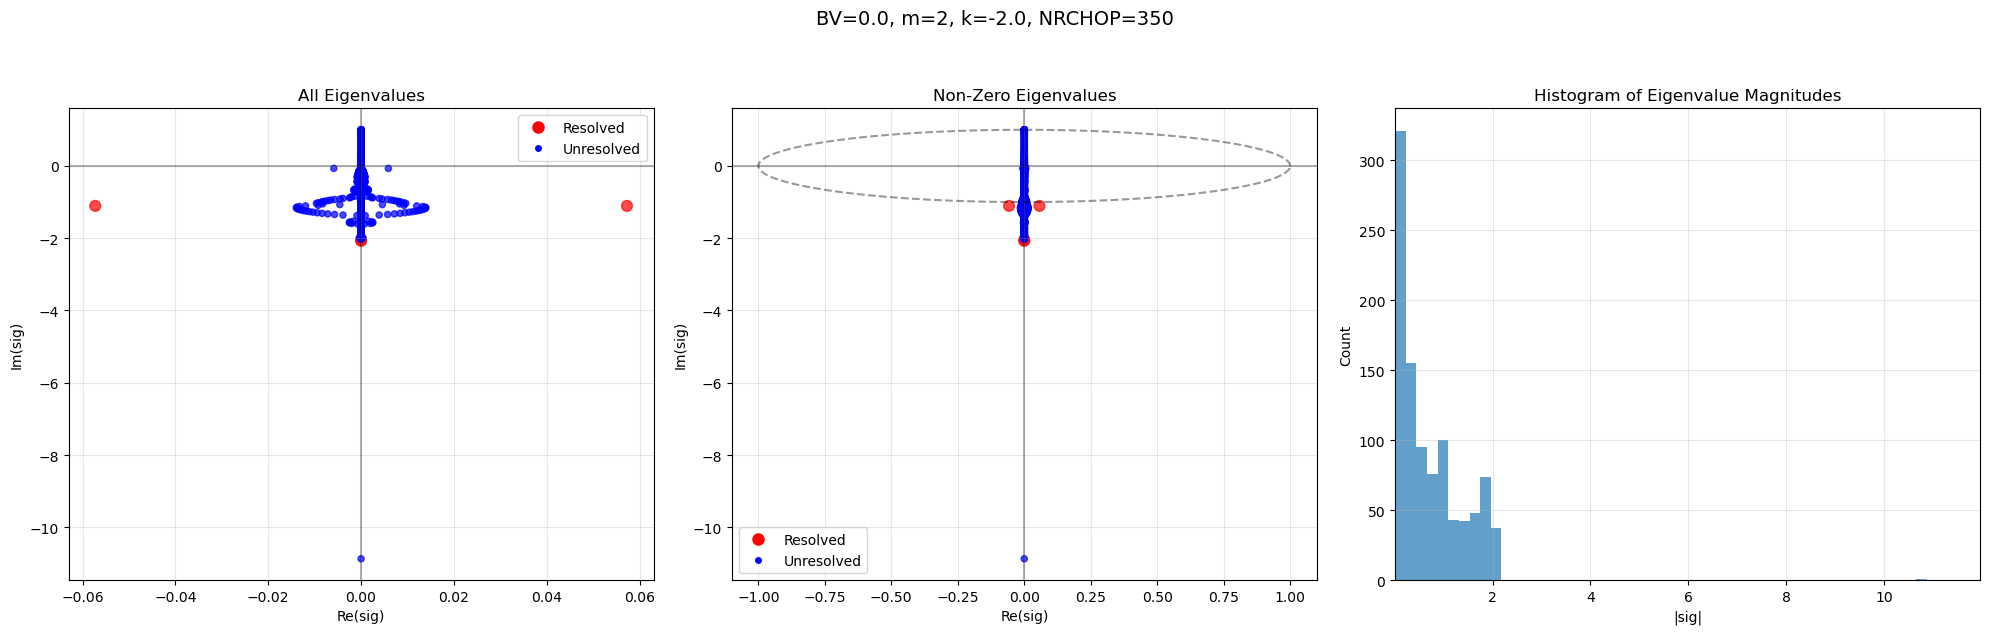

,Parameter,Value
0,BV Frequency,0.0
1,M Value,2
2,K Value,-2.0
3,NRCHOP,350
4,Total Eigenvalues,1044
5,Resolved Eigenvalues,4
6,Resolution Percentage,0.38%


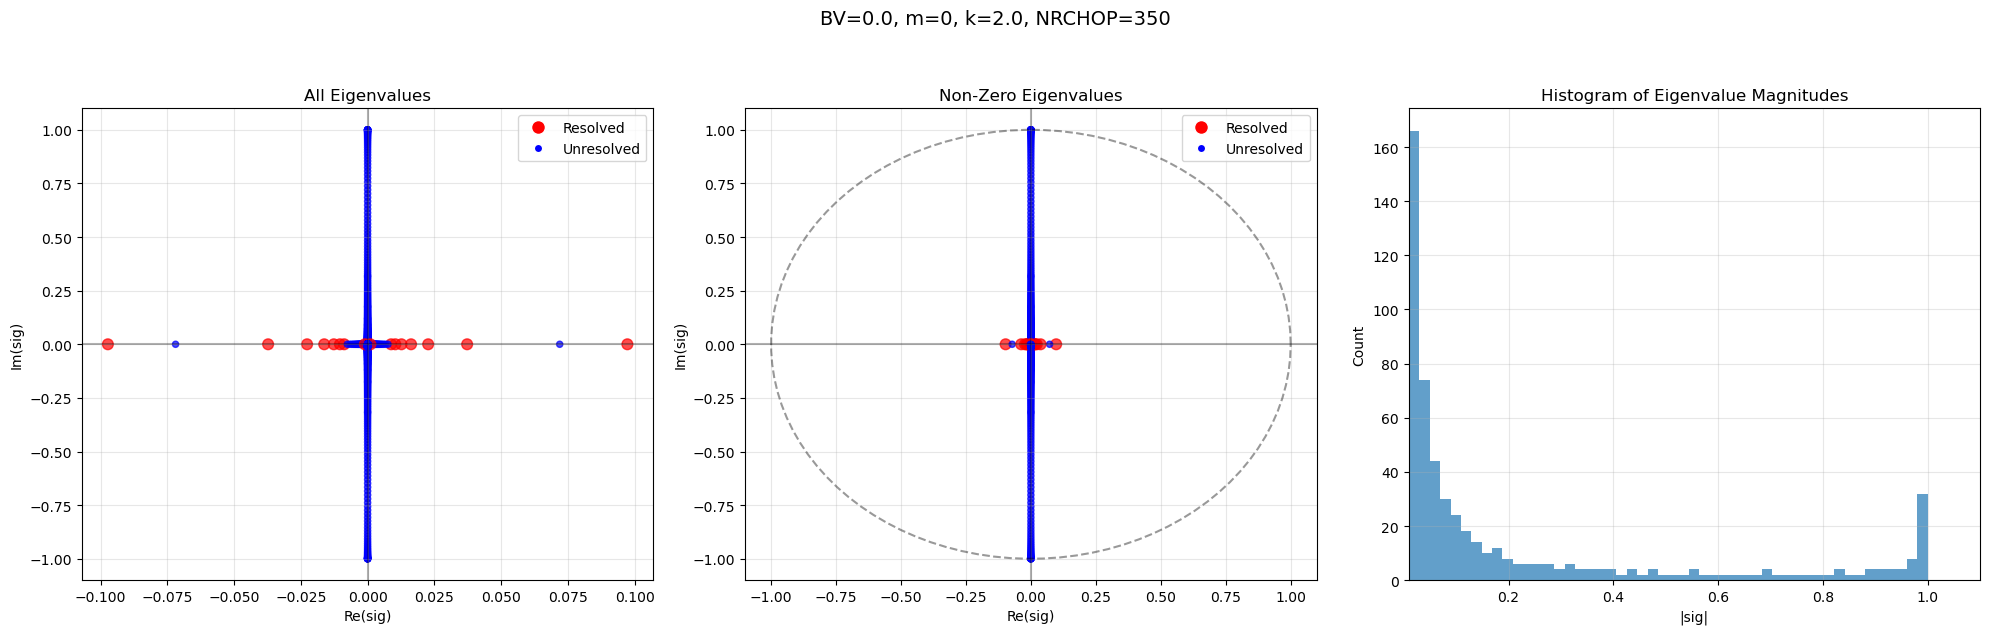

,Parameter,Value
0,BV Frequency,0.0
1,M Value,0
2,K Value,2.0
3,NRCHOP,350
4,Total Eigenvalues,1050
5,Resolved Eigenvalues,16
6,Resolution Percentage,1.52%


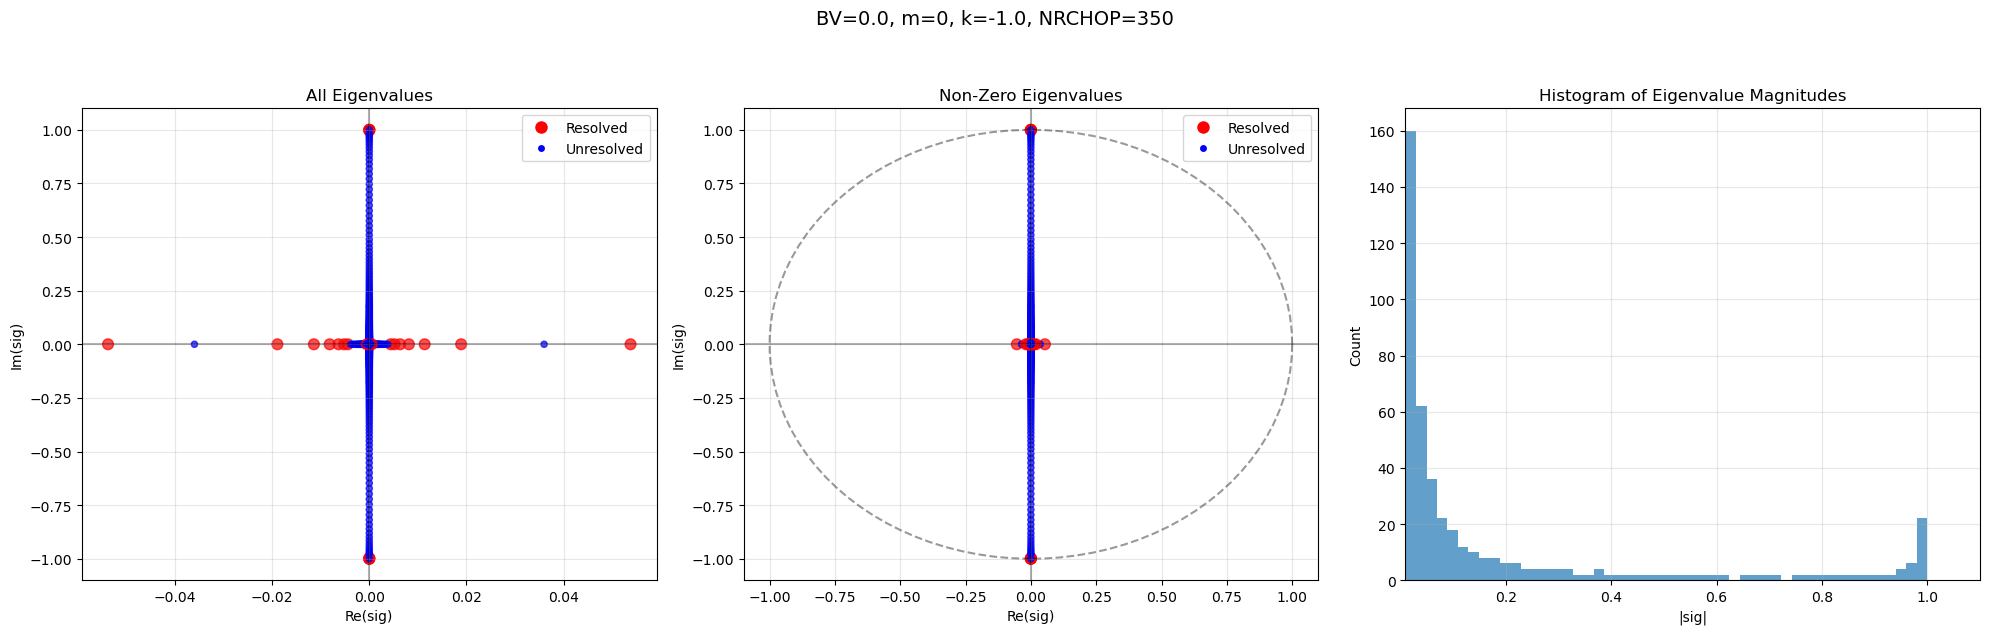

,Parameter,Value
0,BV Frequency,0.0
1,M Value,0
2,K Value,-1.0
3,NRCHOP,350
4,Total Eigenvalues,1050
5,Resolved Eigenvalues,24
6,Resolution Percentage,2.29%


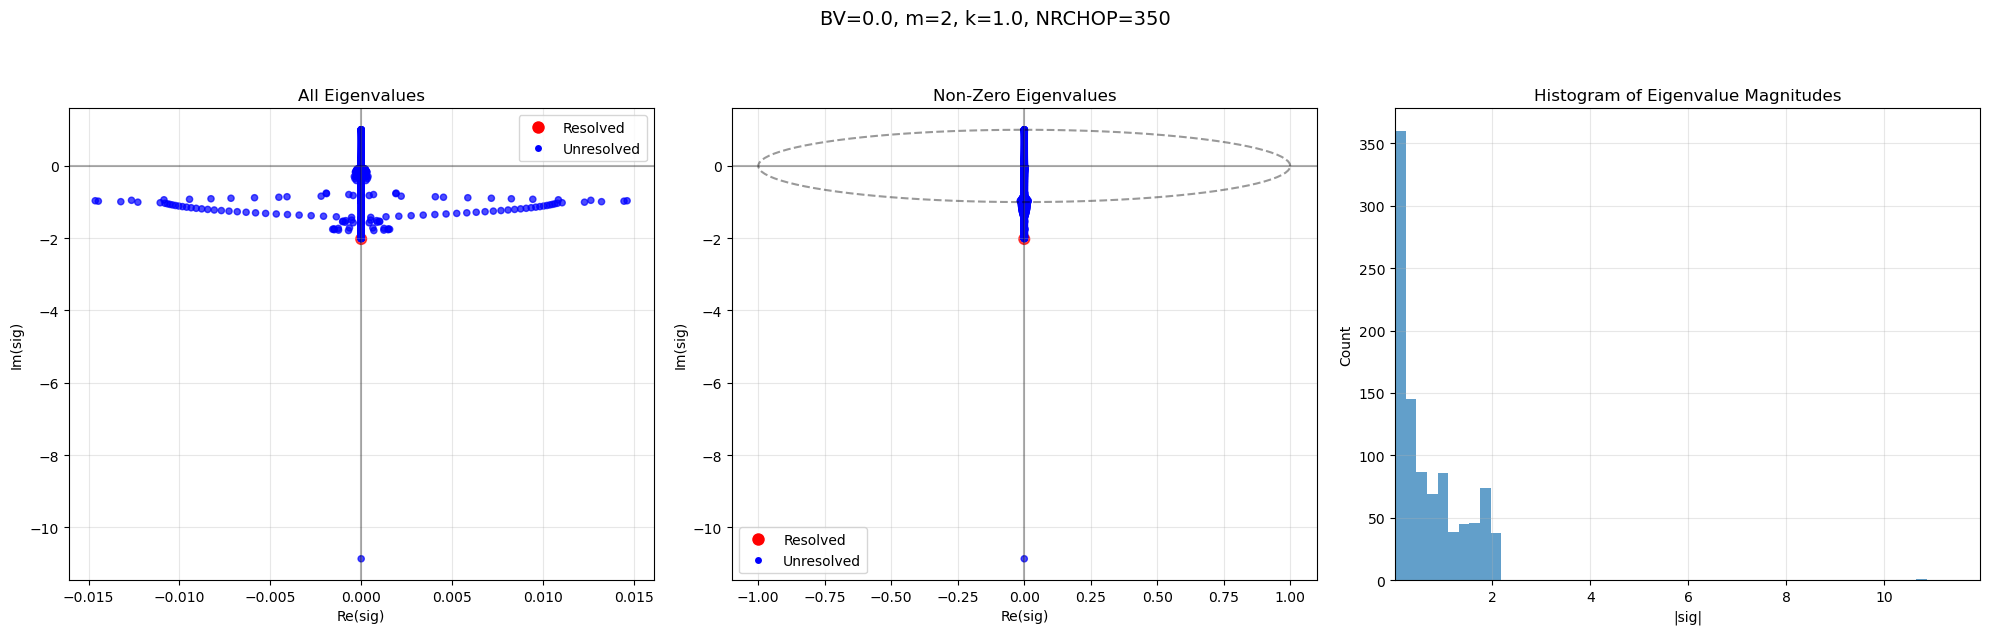

,Parameter,Value
0,BV Frequency,0.0
1,M Value,2
2,K Value,1.0
3,NRCHOP,350
4,Total Eigenvalues,1044
5,Resolved Eigenvalues,1
6,Resolution Percentage,0.10%


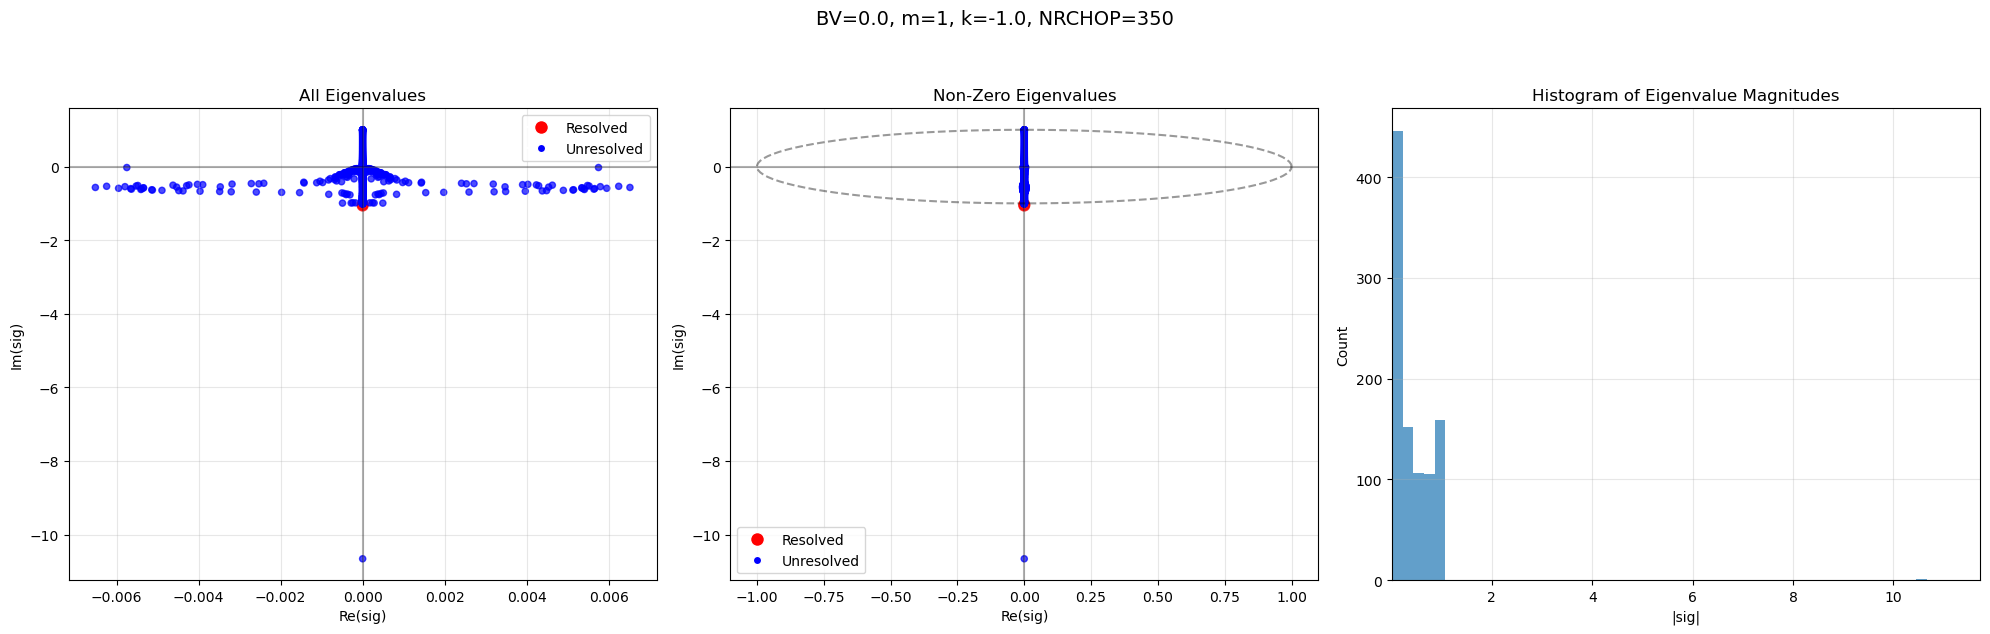

,Parameter,Value
0,BV Frequency,0.0
1,M Value,1
2,K Value,-1.0
3,NRCHOP,350
4,Total Eigenvalues,1047
5,Resolved Eigenvalues,2
6,Resolution Percentage,0.19%


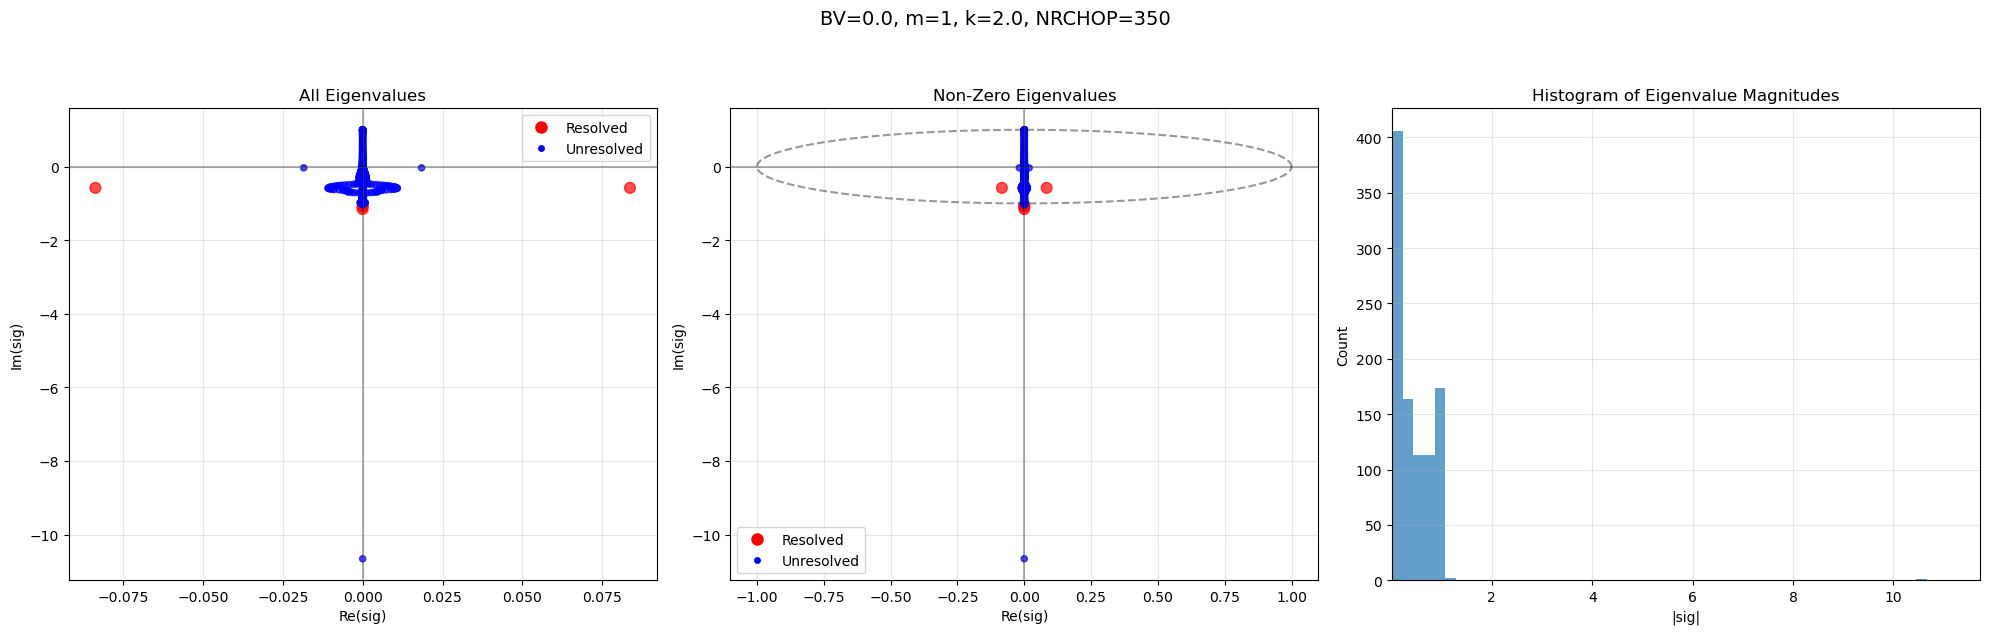

,Parameter,Value
0,BV Frequency,0.0
1,M Value,1
2,K Value,2.0
3,NRCHOP,350
4,Total Eigenvalues,1047
5,Resolved Eigenvalues,5
6,Resolution Percentage,0.48%


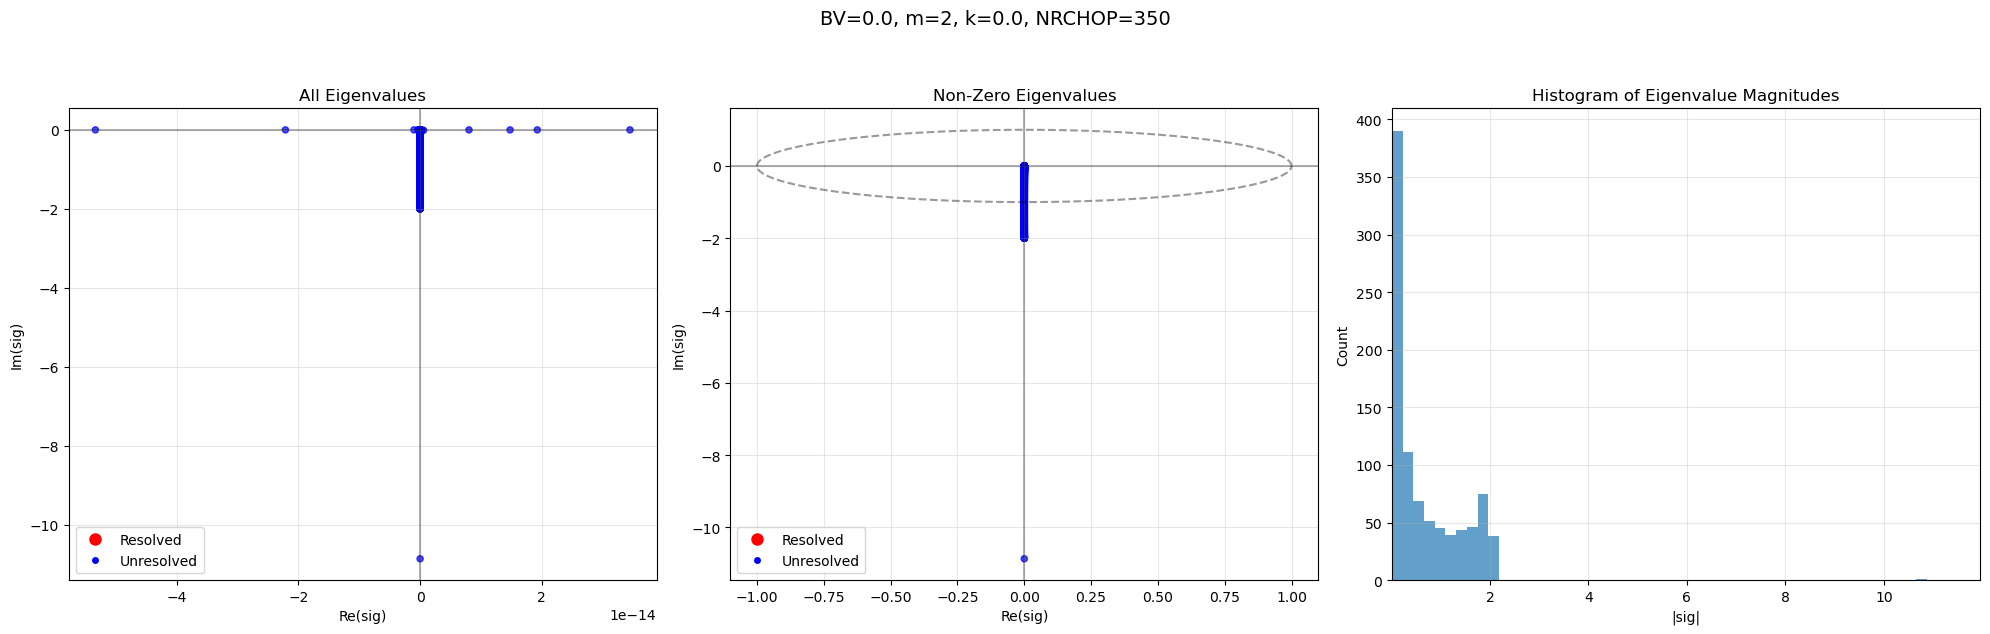

,Parameter,Value
0,BV Frequency,0.0
1,M Value,2
2,K Value,0.0
3,NRCHOP,350
4,Total Eigenvalues,1044
5,Resolved Eigenvalues,0
6,Resolution Percentage,0.00%


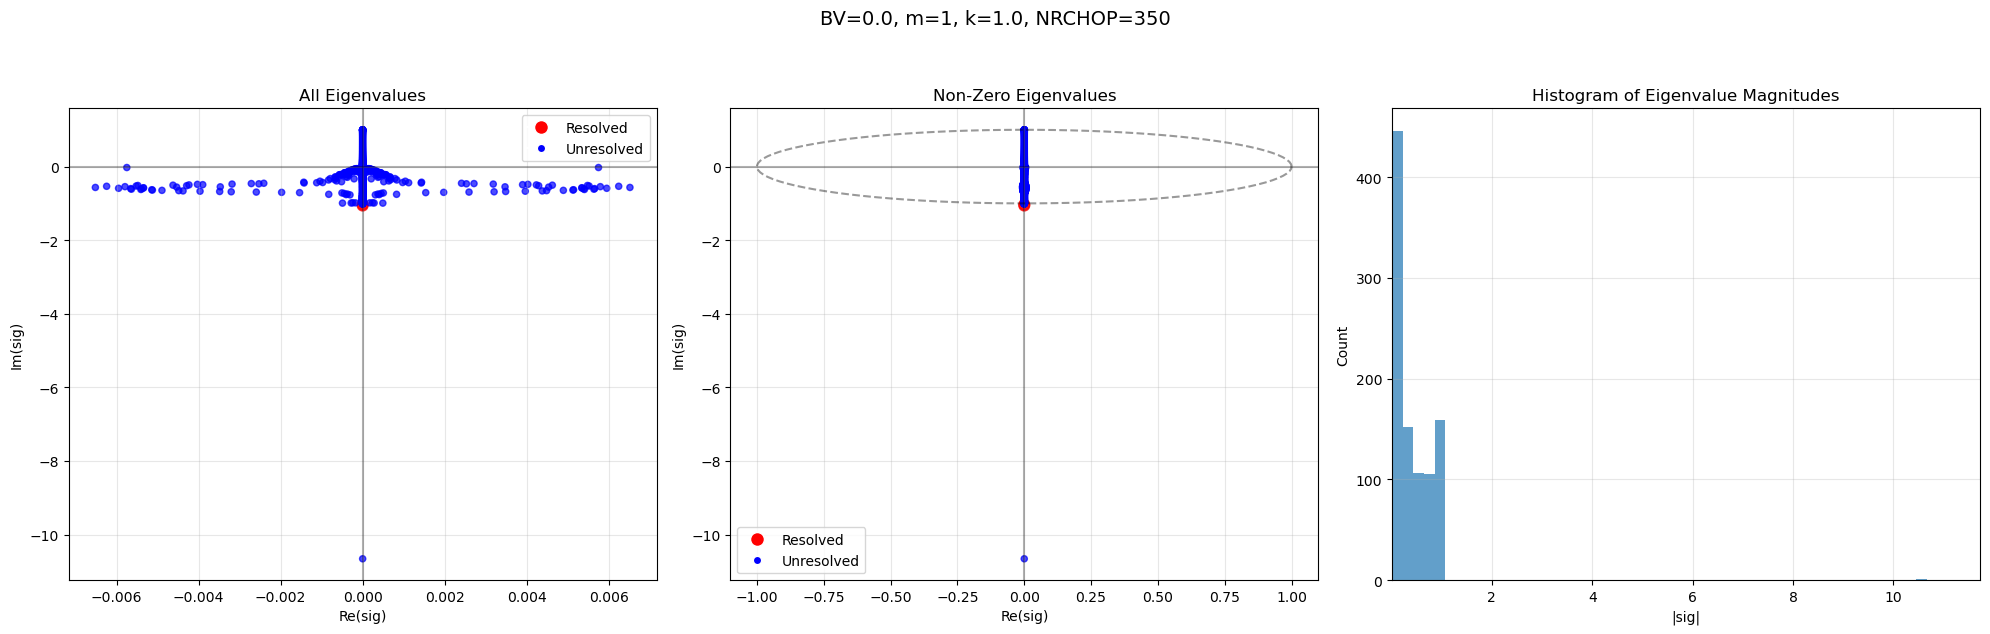

,Parameter,Value
0,BV Frequency,0.0
1,M Value,1
2,K Value,1.0
3,NRCHOP,350
4,Total Eigenvalues,1047
5,Resolved Eigenvalues,2
6,Resolution Percentage,0.19%


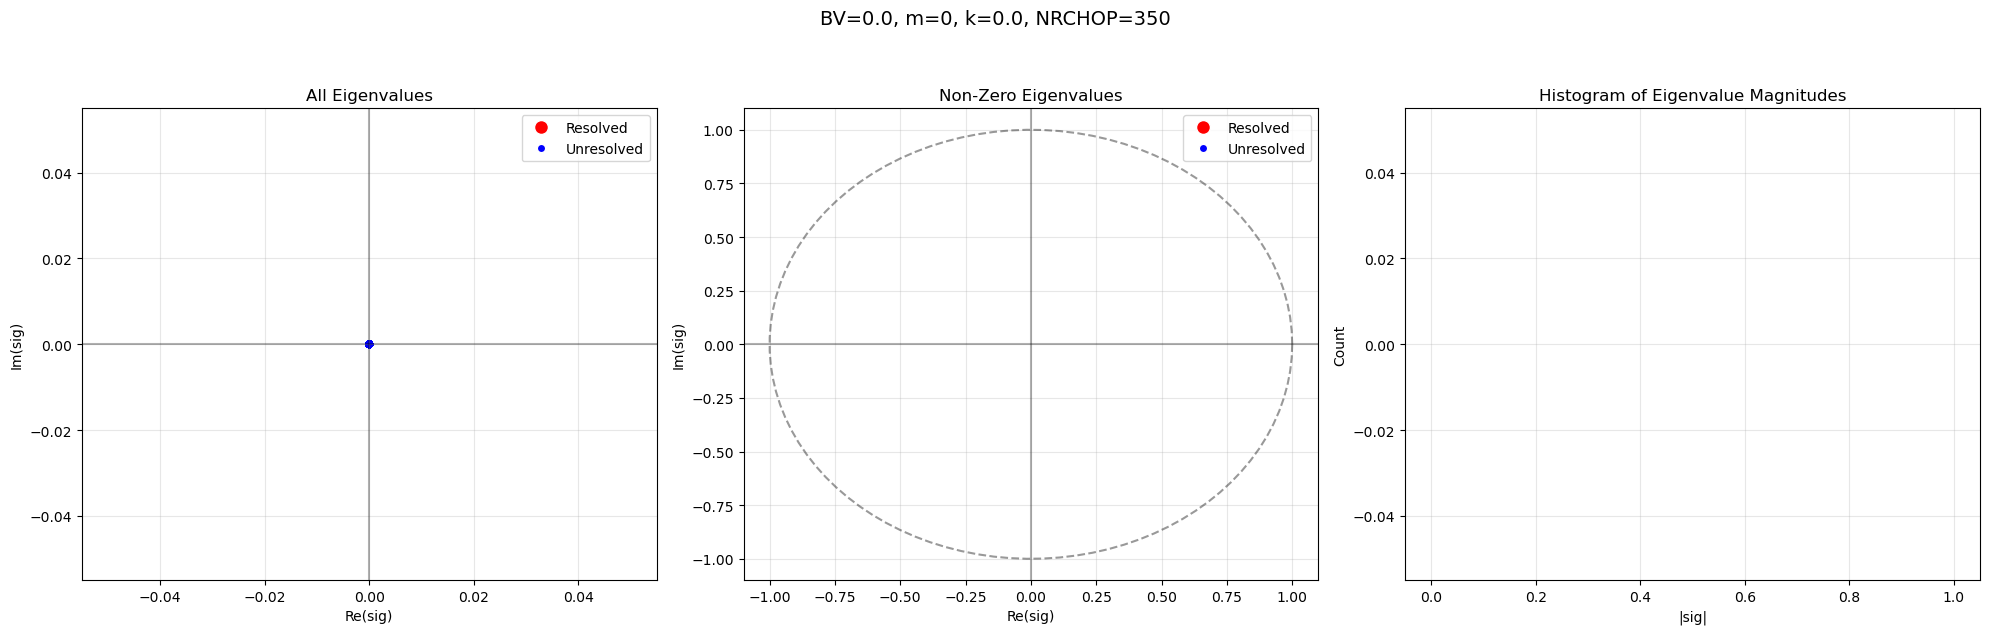

,Parameter,Value
0,BV Frequency,0.0
1,M Value,0
2,K Value,0.0
3,NRCHOP,350
4,Total Eigenvalues,1050
5,Resolved Eigenvalues,0
6,Resolution Percentage,0.00%


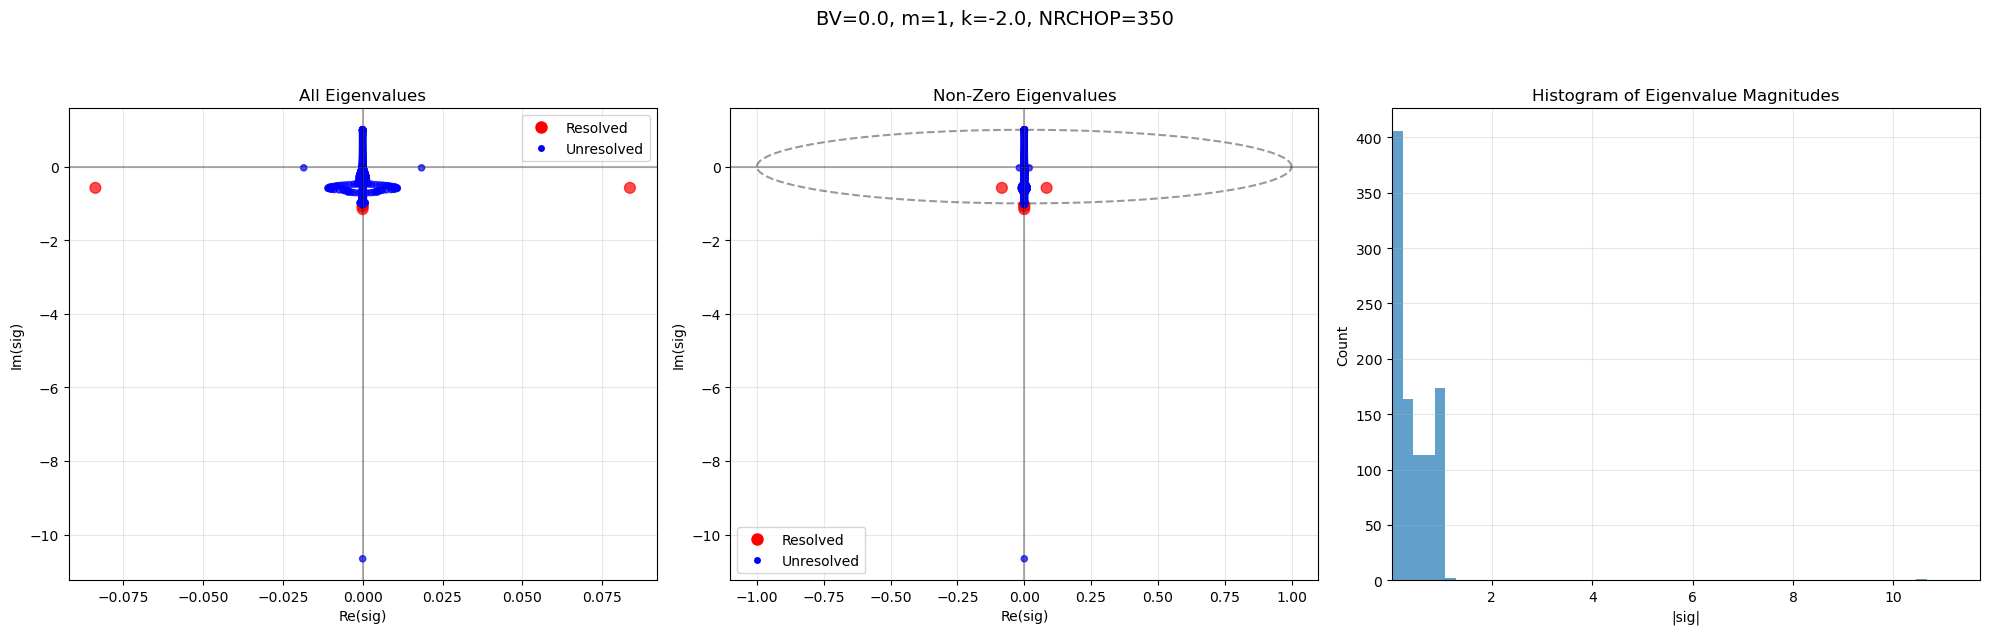

,Parameter,Value
0,BV Frequency,0.0
1,M Value,1
2,K Value,-2.0
3,NRCHOP,350
4,Total Eigenvalues,1047
5,Resolved Eigenvalues,5
6,Resolution Percentage,0.48%


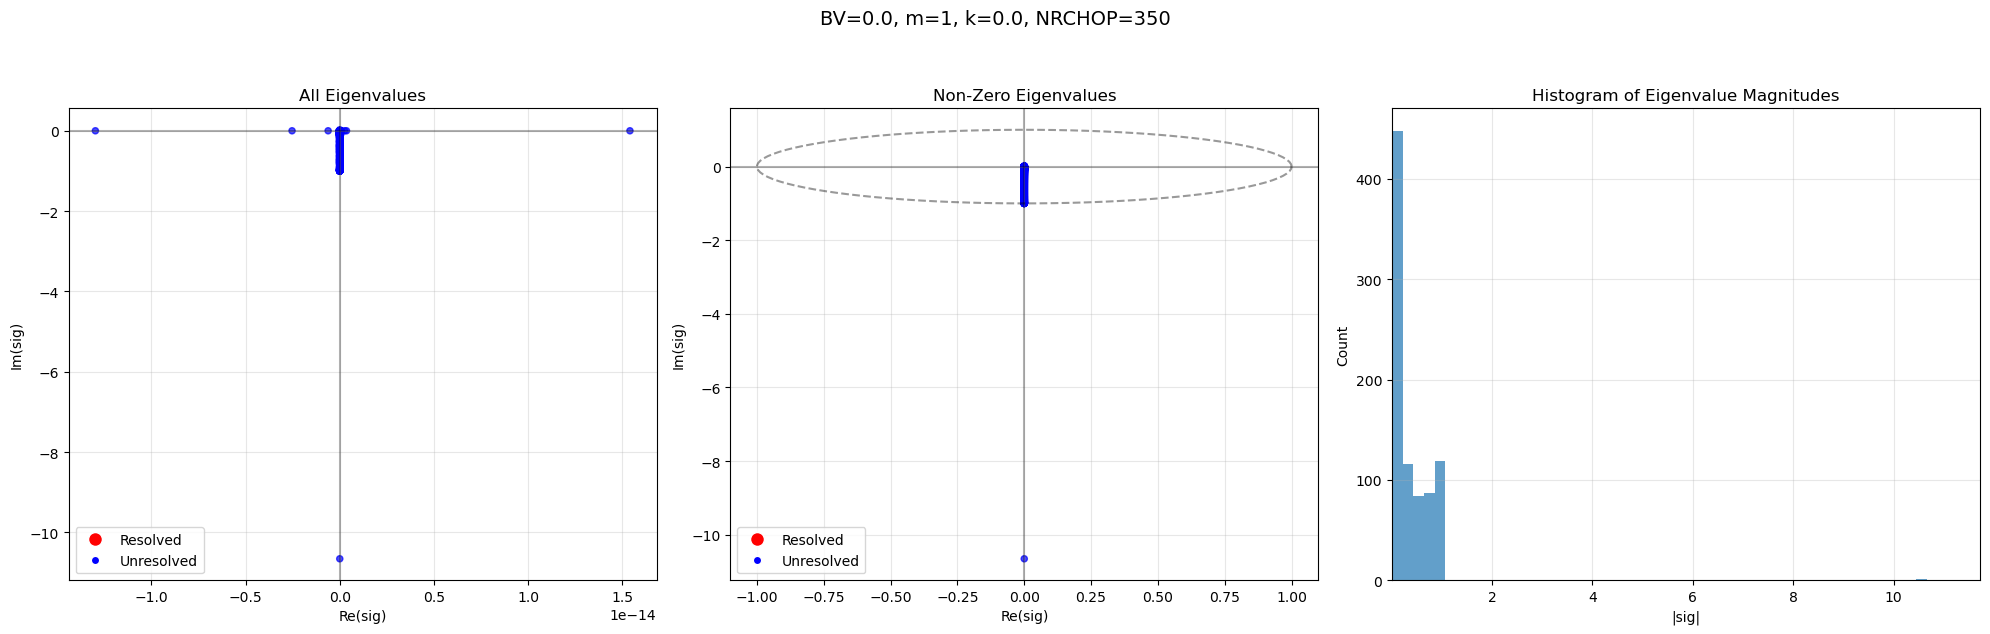

,Parameter,Value
0,BV Frequency,0.0
1,M Value,1
2,K Value,0.0
3,NRCHOP,350
4,Total Eigenvalues,1047
5,Resolved Eigenvalues,0
6,Resolution Percentage,0.00%


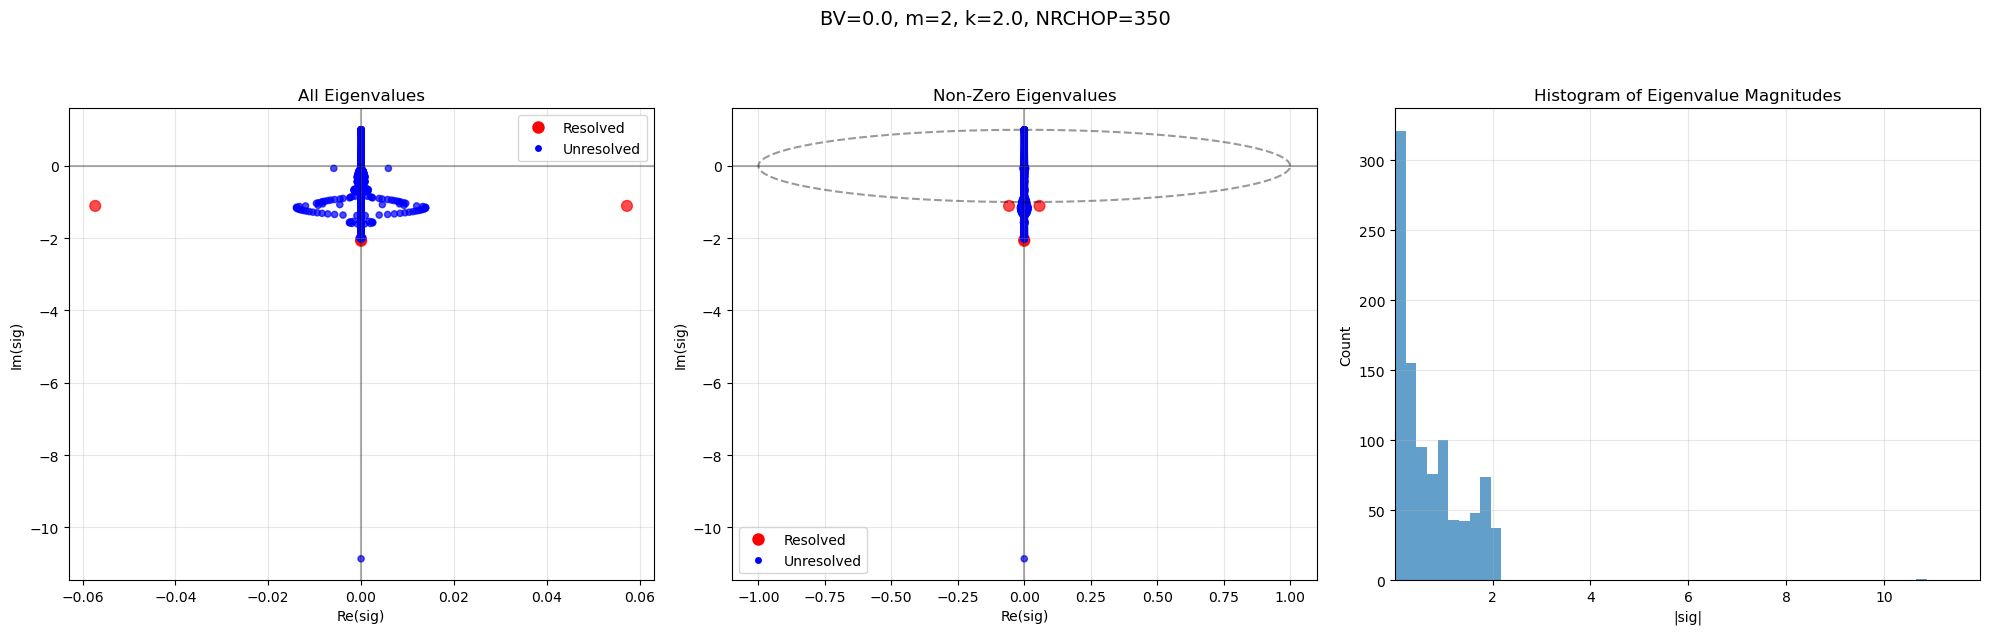

,Parameter,Value
0,BV Frequency,0.0
1,M Value,2
2,K Value,2.0
3,NRCHOP,350
4,Total Eigenvalues,1044
5,Resolved Eigenvalues,4
6,Resolution Percentage,0.38%


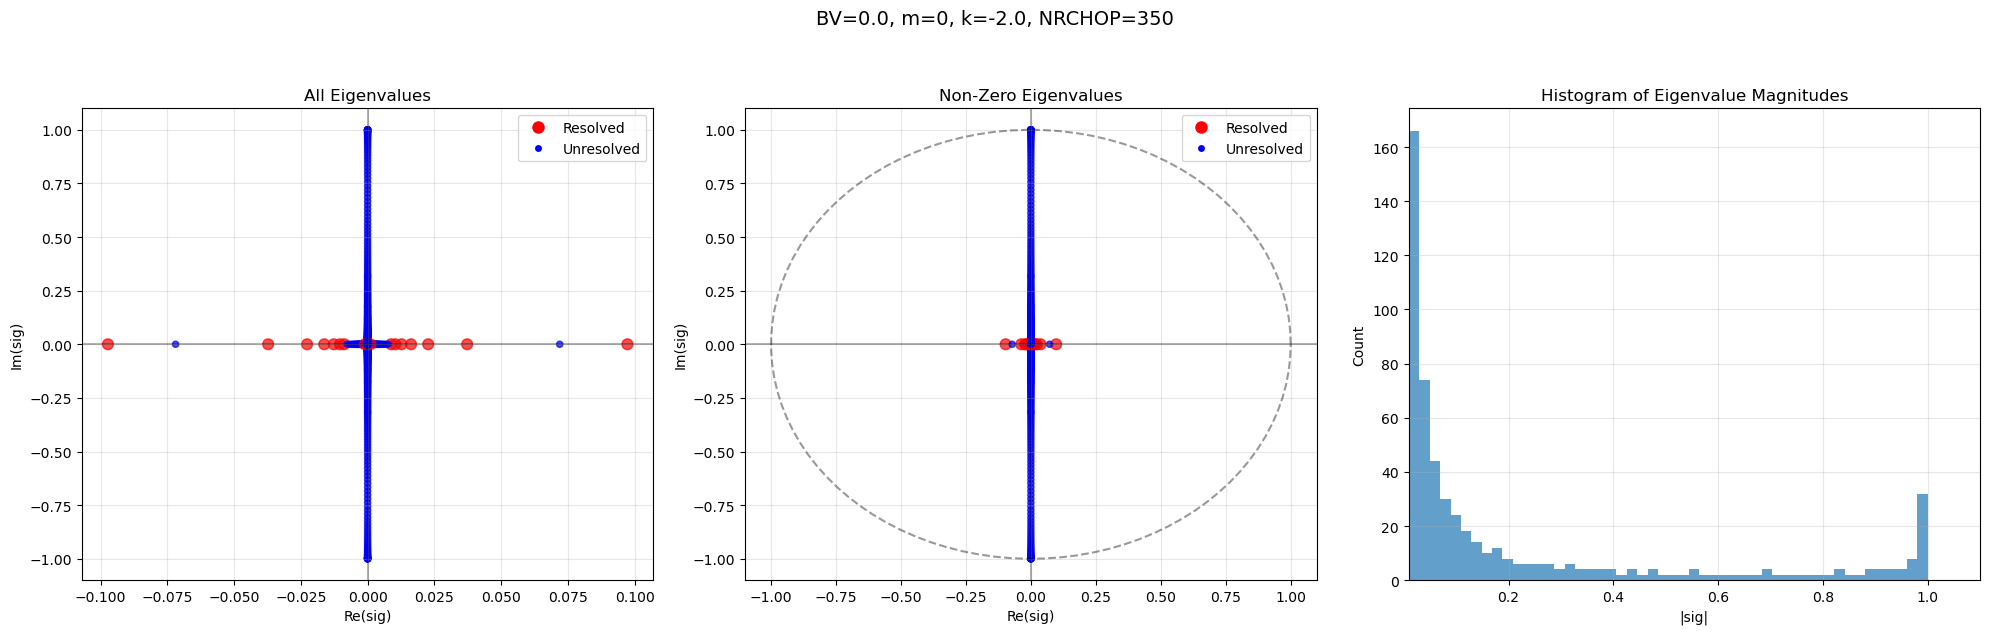

,Parameter,Value
0,BV Frequency,0.0
1,M Value,0
2,K Value,-2.0
3,NRCHOP,350
4,Total Eigenvalues,1050
5,Resolved Eigenvalues,16
6,Resolution Percentage,1.52%


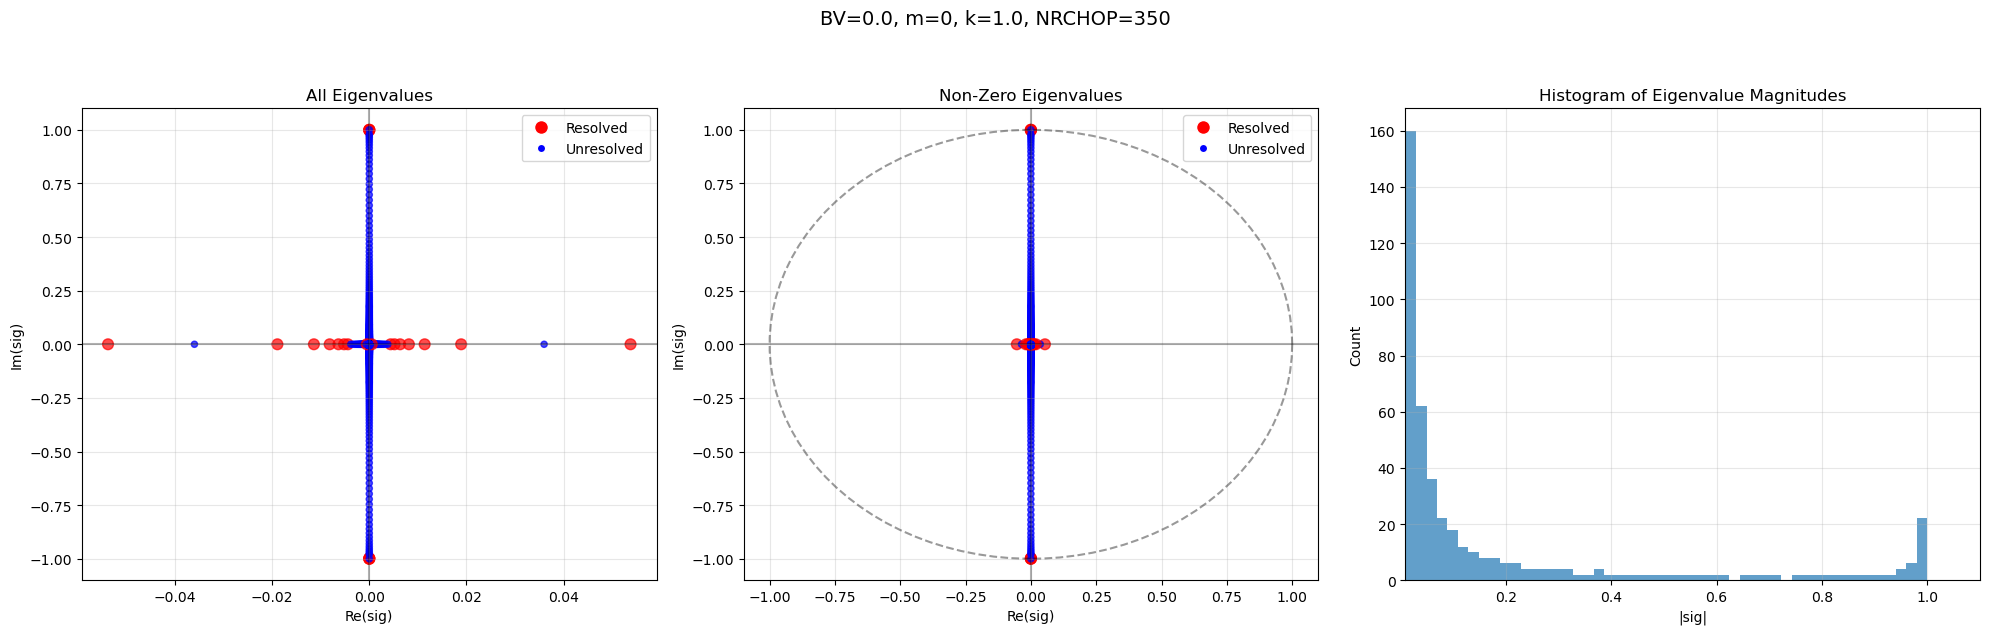

,Parameter,Value
0,BV Frequency,0.0
1,M Value,0
2,K Value,1.0
3,NRCHOP,350
4,Total Eigenvalues,1050
5,Resolved Eigenvalues,24
6,Resolution Percentage,2.29%


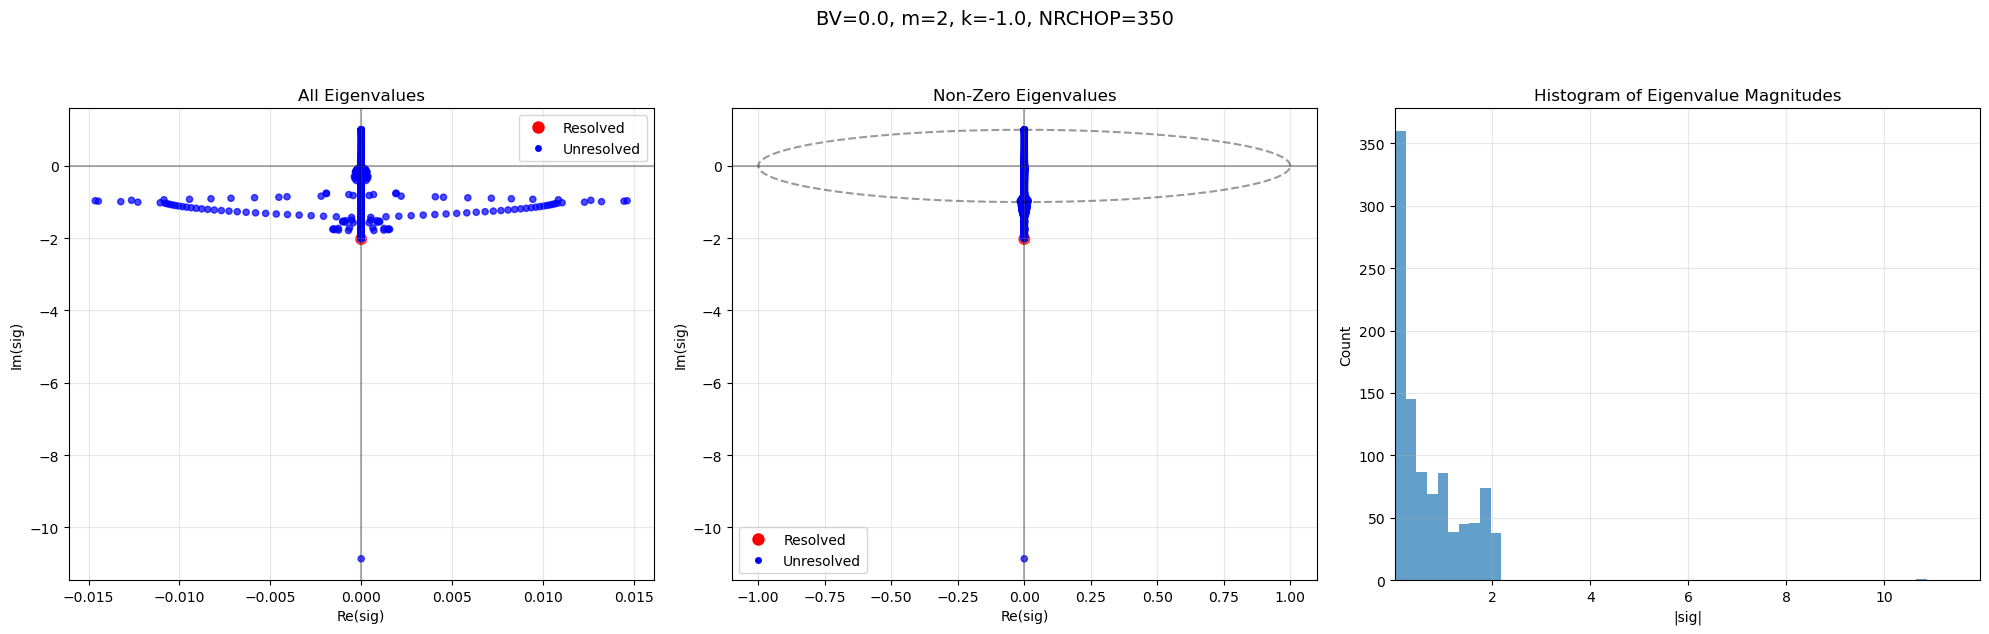

,Parameter,Value
0,BV Frequency,0.0
1,M Value,2
2,K Value,-1.0
3,NRCHOP,350
4,Total Eigenvalues,1044
5,Resolved Eigenvalues,1
6,Resolution Percentage,0.10%


In [5]:
from matplotlib.lines import Line2D

# Find all eigenvalue files
# data_dir = 'data'
data_dir = "/Users/jinge/Projects/MLegS-dev/MLegS/data"
files = glob.glob(os.path.join(data_dir, 'bsnsq_eig_MK_*.output'))

# Process all files
all_data = []
for file in files:
    data = parse_eigenvalue_file(file)
    if data:
        all_data.append(data)

print(f"Processed {len(all_data)} files.")

for data in all_data:
    eigenvalues = data['eigenvalues']
    is_resolved = data['is_resolved']
    
    # Create colormap for resolved vs unresolved
    colors = np.where(is_resolved, 'red', 'blue')
    sizes = np.where(is_resolved, 60, 20)
    
    # Create a figure with 1x3 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
    
    # Plot 1: All eigenvalues in complex plane
    ax1.scatter(eigenvalues.real, eigenvalues.imag, c=colors, s=sizes, alpha=0.7)
    ax1.set_xlabel('Re(sig)')
    ax1.set_ylabel('Im(sig)')
    ax1.set_title('All Eigenvalues')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    # Plot 2: Non-zero eigenvalues
    mask = (abs(eigenvalues) > 1e-10)
    filtered_values = eigenvalues[mask]
    filtered_resolved = is_resolved[mask]
    filtered_colors = np.where(filtered_resolved, 'red', 'blue')
    filtered_sizes = np.where(filtered_resolved, 60, 20)
    
    ax2.scatter(filtered_values.real, filtered_values.imag, c=filtered_colors, s=filtered_sizes, alpha=0.7)
    ax2.set_xlabel('Re(sig)')
    ax2.set_ylabel('Im(sig)')
    ax2.set_title('Non-Zero Eigenvalues')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax2.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    # Add unit circle for reference
    theta = np.linspace(0, 2*np.pi, 100)
    ax2.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.4)
    
    # Plot 3: Histogram of eigenvalue magnitudes
    magnitudes = np.abs(eigenvalues)
    ax3.hist(magnitudes[magnitudes > 0.01], bins=50, alpha=0.7)
    ax3.set_xlabel('|sig|')
    ax3.set_ylabel('Count')
    ax3.set_title('Histogram of Eigenvalue Magnitudes')
    ax3.grid(True, alpha=0.3)
    # Set x-axis range based on non-zero magnitudes
    non_zero_mags = magnitudes[magnitudes > 0.01]
    if len(non_zero_mags) > 0:
        ax3.set_xlim([min(non_zero_mags) * 0.9, max(non_zero_mags) * 1.1])
    
    # Create custom legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Resolved'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=6, label='Unresolved')
    ]
    
    # Add legend to the first two plots
    ax1.legend(handles=legend_elements, loc='best')
    ax2.legend(handles=legend_elements, loc='best')
    
    # Add main title with parameters
    fig.suptitle(f'BV={data["bv_freq"]}, m={data["m"]}, k={data["k"]}, NRCHOP={data["nrchop"]}', 
                fontsize=14, y=1.05)
    
    plt.tight_layout()
    plt.show()
    
    # Display statistics
    stats = pd.DataFrame({
        'Parameter': ['BV Frequency', 'M Value', 'K Value', 'NRCHOP', 
                     'Total Eigenvalues', 'Resolved Eigenvalues', 'Resolution Percentage'],
        'Value': [data['bv_freq'], data['m'], data['k'], data['nrchop'],
                 len(eigenvalues), np.sum(is_resolved), 
                 f"{100 * np.sum(is_resolved) / len(eigenvalues):.2f}%"]
    })
    
    display(stats)
